Gini table:
      Year   Gini
1584  1987  22.07
198   1988  22.06
396   1989  21.93
2970  1990  22.16
2475  1991  21.99
1881  1992  22.34
3366  1993  22.79
594   1994  22.50
3564  1995  22.41
1485  1996  22.83
3663  1997  23.47
1386  1998  23.81
99    1999  23.83
1782  2000  24.38
2772  2001  24.40
3168  2002  24.03
3267  2003  24.14
2376  2004  24.68
1089  2005  25.66
1287  2006  26.28
2079  2007  27.02
495   2008  27.94
891   2009  26.74
2277  2010  27.47
792   2011  27.68
1188  2012  27.37
2178  2013  27.88
3069  2014  28.33
297   2015  28.77
0     2016  28.97
1980  2017  29.32
1683  2018  29.10
2673  2019  29.55
2574  2020  29.72
693   2021  30.28
990   2022  29.96
2871  2023  30.61
3465  2024  30.43

Decile table:
DECILGEN  Year  Decile 1  Decile 10  Decile 2  Decile 3  Decile 4  Decile 5  \
0         1987     31418     169598     59014     68786     77577     85361   
1         1988     32746     178357     62506     72540     81673     89941   
2         1989     35284     18896

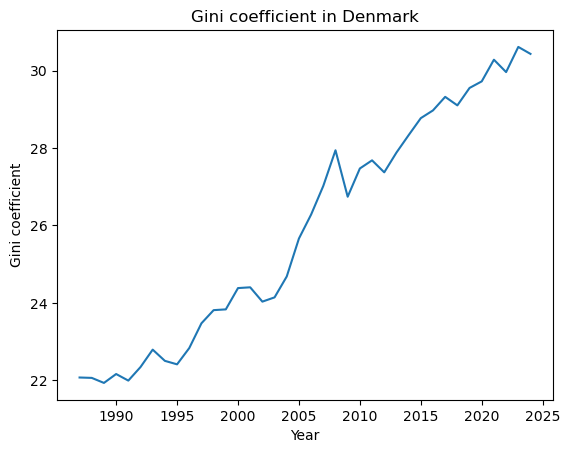

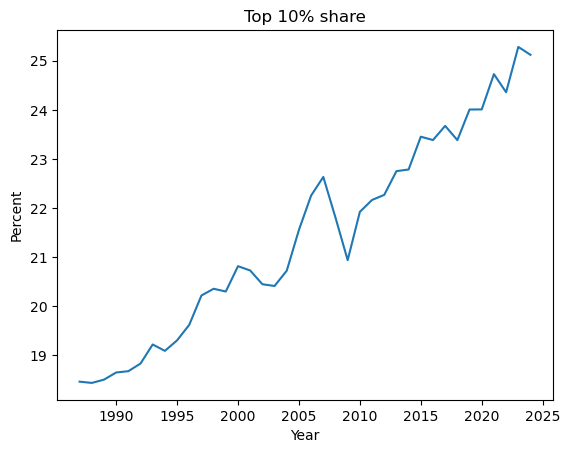


Correlation: 0.981641545052772

Linear minimize: [21.04275353  0.2635496 ]
Linear polyfit: [21.04275304  0.26354962]

Quadratic minimize: [2.13041903e+01 2.19975990e-01 1.17766511e-03]
Quadratic polyfit: [2.13042004e+01 2.19975061e-01 1.17769085e-03]

Year: 2030
Linear prediction: 32.375386125111966
Quadratic prediction: 32.94066064338925

Year: 2040
Linear prediction: 35.010882076520716
Quadratic prediction: 36.27097904643734


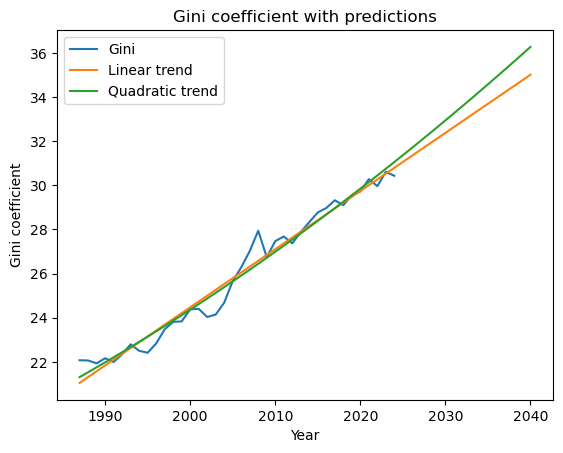

Correlation across municipalities: 0.9747061399602605
Correlation over time: 0.981641545052772

10 most unequal:
        Municipality   Gini
3435        Gentofte  49.04
3453       Rudersdal  47.31
3493           Vejen  46.32
3452        Hørsholm  40.07
3442  Lyngby-Taarbæk  39.28
3431   Frederiksberg  36.54
3430       København  34.97
3511          Aarhus  33.43
3449     Fredensborg  32.76
3450       Helsingør  30.55

10 least unequal:
         Municipality   Gini
3478  Faaborg-Midtfyn  23.77
3454           Egedal  23.85
3475         Bornholm  24.03
3464             Faxe  24.09
3458          Halsnæs  24.41
3505         Favrskov  24.41
3477           Assens  24.46
3514        Hedensted  24.58
3439      Albertslund  24.66
3506            Odder  24.70


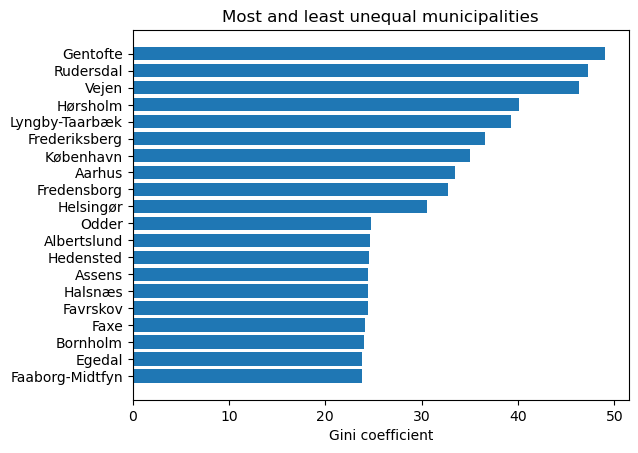


Largest changes:
      Municipality  Change
63           Vejen   25.12
23       Rudersdal   18.26
5         Gentofte   17.94
12  Lyngby-Taarbæk   14.31
0        København   11.92
22        Hørsholm   11.68
19     Fredensborg   11.59
81          Aarhus   11.33
1    Frederiksberg   11.26
16      Vallensbæk   10.80

Smallest changes:
       Municipality  Change
61             Fanø    0.67
55              Ærø    2.35
34             Faxe    2.45
92             Læsø    2.60
45         Bornholm    2.72
48  Faaborg-Midtfyn    2.89
39             Sorø    2.92
38           Stevns    3.42
94    Mariagerfjord    3.67
76            Odder    3.77


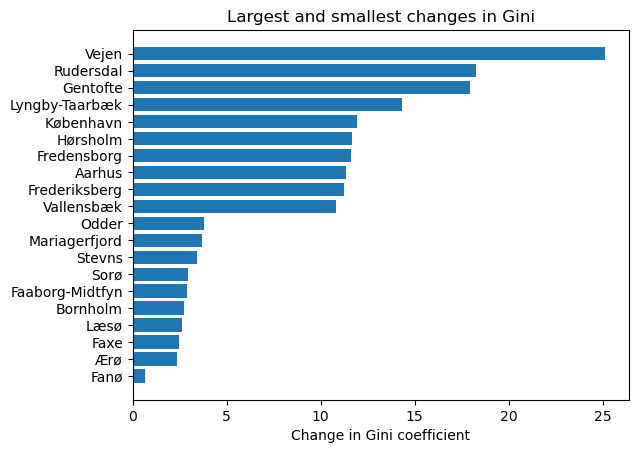

Correlation: 0.6737061940269798


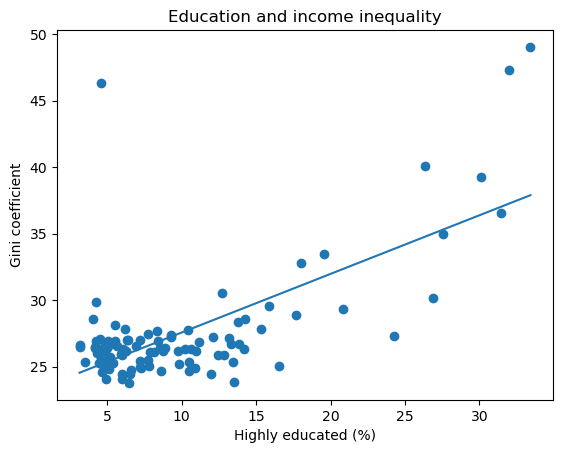

In [11]:
import pandas as pd
from dstapi import DstApi
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize


# Get IFOR41 from API

api41 = DstApi("IFOR41")

params41 = {
    "table": "IFOR41",
    "format": "BULK",
    "lang": "da",
    "variables": [
        {"code": "ULLIG", "values": ["70"]},
        {"code": "KOMMUNEDK", "values": ["*"]},
        {"code": "Tid", "values": ["*"]}
    ]
}

ifor41 = api41.get_data(params=params41)


# Get IFOR32 from API

api32 = DstApi("IFOR32")

params32 = {
    "table": "IFOR32",
    "format": "BULK",
    "lang": "da",
    "variables": [
        {"code": "DECILGEN", "values": ["*"]},
        {"code": "KOMMUNEDK", "values": ["*"]},
        {"code": "Tid", "values": ["*"]}
    ]
}

ifor32 = api32.get_data(params=params32)


# 1.1 The Gini coefficient and the top 10 percent share

# Denmark only

ifor41_dk = ifor41[ifor41["KOMMUNEDK"] == "Hele landet"].copy()
ifor32_dk = ifor32[ifor32["KOMMUNEDK"] == "Hele landet"].copy()


# Gini table

gini_table = ifor41_dk[["TID", "INDHOLD"]].copy()
gini_table.columns = ["Year", "Gini"]

gini_table["Year"] = pd.to_numeric(gini_table["Year"])
gini_table["Gini"] = pd.to_numeric(gini_table["Gini"])

gini_table = gini_table.sort_values("Year")

print("Gini table:")
print(gini_table)


# Decile table

ifor32_dk["INDHOLD"] = pd.to_numeric(ifor32_dk["INDHOLD"], errors="coerce")

decile_table = ifor32_dk.pivot(
    index="TID",
    columns="DECILGEN",
    values="INDHOLD"
).reset_index()

decile_table = decile_table.rename(columns={
    "TID": "Year",
    "1. decil": "Decile 1",
    "2. decil": "Decile 2",
    "3. decil": "Decile 3",
    "4. decil": "Decile 4",
    "5. decil": "Decile 5",
    "6. decil": "Decile 6",
    "7. decil": "Decile 7",
    "8. decil": "Decile 8",
    "9. decil": "Decile 9",
    "10. decil": "Decile 10"
})

decile_table["Year"] = pd.to_numeric(decile_table["Year"])

decile_table["Top 10 share"] = (
    decile_table["Decile 10"] /
    decile_table.iloc[:, 1:11].sum(axis=1) * 100
)

decile_table = decile_table.sort_values("Year")

print("\nDecile table:")
print(decile_table)


# Plot Gini

plt.plot(gini_table["Year"], gini_table["Gini"])
plt.title("Gini coefficient in Denmark")
plt.xlabel("Year")
plt.ylabel("Gini coefficient")
plt.show()


# Merge the two measures

data = pd.merge(
    gini_table,
    decile_table[["Year", "Top 10 share"]],
    on="Year",
    validate="1:1"
)


# Plot top 10 share

plt.plot(data["Year"], data["Top 10 share"])

plt.title("Top 10% share")
plt.xlabel("Year")
plt.ylabel("Percent")
plt.show()


# Correlation

correlation = data["Gini"].corr(data["Top 10 share"])

print("\nCorrelation:", correlation)


# 1.2 Prediction

t = gini_table["Year"] - 1987
y = gini_table["Gini"]


# Linear trend

def linear(beta):
    y_hat = beta[0] + beta[1] * t
    return np.sum((y - y_hat)**2)

lin = minimize(linear, [0, 0])
b_lin = lin.x


# Quadratic trend

def quadratic(beta):
    y_hat = beta[0] + beta[1] * t + beta[2] * t**2
    return np.sum((y - y_hat)**2)

quad = minimize(quadratic, [0, 0, 0])
b_quad = quad.x


# Compare with np.polyfit

poly_lin = np.polyfit(t, y, 1)[::-1]
poly_quad = np.polyfit(t, y, 2)[::-1]

print("\nLinear minimize:", b_lin)
print("Linear polyfit:", poly_lin)

print("\nQuadratic minimize:", b_quad)
print("Quadratic polyfit:", poly_quad)


# Predictions for 2030 and 2040

for year in [2030, 2040]:

    x = year - 1987

    lin_pred = b_lin[0] + b_lin[1] * x
    quad_pred = b_quad[0] + b_quad[1] * x + b_quad[2] * x**2

    print("\nYear:", year)
    print("Linear prediction:", lin_pred)
    print("Quadratic prediction:", quad_pred)


# Plot predictions

years = np.arange(1987, 2041)
x = years - 1987

lin_fit = b_lin[0] + b_lin[1] * x
quad_fit = b_quad[0] + b_quad[1] * x + b_quad[2] * x**2

plt.plot(gini_table["Year"], gini_table["Gini"], label="Gini")
plt.plot(years, lin_fit, label="Linear trend")
plt.plot(years, quad_fit, label="Quadratic trend")

plt.title("Gini coefficient with predictions")
plt.xlabel("Year")
plt.ylabel("Gini coefficient")
plt.legend()
plt.show()


# 1.3 Municipalities

# Remove all of Denmark
gini_mun = ifor41[ifor41["KOMMUNEDK"] != "Hele landet"].copy()
decile_mun = ifor32[ifor32["KOMMUNEDK"] != "Hele landet"].copy()

gini_mun["INDHOLD"] = pd.to_numeric(gini_mun["INDHOLD"])
decile_mun["INDHOLD"] = pd.to_numeric(decile_mun["INDHOLD"])

# Make decile table
decile_mun = decile_mun.pivot(
    index=["KOMMUNEDK", "TID"],
    columns="DECILGEN",
    values="INDHOLD"
).reset_index()

deciles = [f"{i}. decil" for i in range(1, 11)]

decile_mun["Top 10 share"] = (
    decile_mun["10. decil"] /
    decile_mun[deciles].sum(axis=1) * 100
)

# Merge Gini and top 10 share
mun_data = pd.merge(
    gini_mun[["KOMMUNEDK", "TID", "INDHOLD"]],
    decile_mun[["KOMMUNEDK", "TID", "Top 10 share"]],
    on=["KOMMUNEDK", "TID"],
    validate="1:1"
)

mun_data.columns = ["Municipality", "Year", "Gini", "Top 10 share"]
mun_data["Year"] = pd.to_numeric(mun_data["Year"])


# 1. Correlation across municipalities

latest_year = mun_data["Year"].max()
latest = mun_data[mun_data["Year"] == latest_year]

correlation_mun = latest["Gini"].corr(latest["Top 10 share"])

print("Correlation across municipalities:", correlation_mun)
print("Correlation over time:", correlation)


# 2. Most and least unequal municipalities

most = latest.nlargest(10, "Gini")
least = latest.nsmallest(10, "Gini")

print("\n10 most unequal:")
print(most[["Municipality", "Gini"]])

print("\n10 least unequal:")
print(least[["Municipality", "Gini"]])

ranking = pd.concat([most, least]).sort_values("Gini")

plt.barh(ranking["Municipality"], ranking["Gini"])
plt.title("Most and least unequal municipalities")
plt.xlabel("Gini coefficient")
plt.show()



# 3. Change in Gini

first_year = mun_data["Year"].min()

first = mun_data[mun_data["Year"] == first_year]
last = mun_data[mun_data["Year"] == latest_year]

change = pd.merge(
    first[["Municipality", "Gini"]],
    last[["Municipality", "Gini"]],
    on="Municipality",
    suffixes=("_first", "_last")
)

change["Change"] = change["Gini_last"] - change["Gini_first"]

largest = change.nlargest(10, "Change")
smallest = change.nsmallest(10, "Change")

print("\nLargest changes:")
print(largest[["Municipality", "Change"]])

print("\nSmallest changes:")
print(smallest[["Municipality", "Change"]])

change_plot = pd.concat([largest, smallest]).sort_values("Change")

plt.barh(change_plot["Municipality"], change_plot["Change"])
plt.title("Largest and smallest changes in Gini")
plt.xlabel("Change in Gini coefficient")
plt.show()

# 1.4 Extension

api_edu = DstApi("LIGEUB1")

params_edu = {
    "table": "LIGEUB1",
    "format": "BULK",
    "lang": "da",
    "variables": [
        {"code": "BOPOMR", "values": ["*"]},
        {"code": "HERKOMST", "values": ["*"]},
        {"code": "HFUDD", "values": ["*"]},
        {"code": "ALDER", "values": ["*"]},
        {"code": "KØN", "values": ["*"]},
        {"code": "Tid", "values": ["2024"]}
    ]
}

education = api_edu.get_data(params=params_edu)

education["INDHOLD"] = pd.to_numeric(
    education["INDHOLD"],
    errors="coerce"
)

# Keep totals for origin, age and sex
education = education[
    (education["HERKOMST"] == "I alt") &
    (education["ALDER"] == "Alder i alt") &
    (education["KØN"] == "I alt")
]


# Total population
total = education[
    education["HFUDD"] == "I alt"
][["BOPOMR", "INDHOLD"]]

total.columns = ["Municipality", "Total"]


# Long education + PhD
high = education[
    education["HFUDD"].isin([
        "H70 Lange videregående uddannelser, LVU",
        "H80 Ph.d. og forskeruddannelser"
    ])
]

high = high.groupby("BOPOMR")["INDHOLD"].sum().reset_index()
high.columns = ["Municipality", "High education"]


# Share with high education
edu = pd.merge(total, high, on="Municipality")

edu["High education share"] = (
    edu["High education"] / edu["Total"] * 100
)


# Merge with Gini
extension = pd.merge(
    latest[["Municipality", "Gini"]],
    edu[["Municipality", "High education share"]],
    on="Municipality"
)


# Correlation
corr_edu = extension["Gini"].corr(
    extension["High education share"]
)

print("Correlation:", corr_edu)


# Figure
x = extension["High education share"]
y = extension["Gini"]

a, b = np.polyfit(x, y, 1)

plt.scatter(x, y)
plt.plot(x.sort_values(), a * x.sort_values() + b)

plt.xlabel("Highly educated (%)")
plt.ylabel("Gini coefficient")
plt.title("Education and income inequality")

plt.show()
